# What drives Ontario's electricity demand?

*Twenty years of hourly grid data, twenty years of weather, and what they tell a forecaster.*

Every hour of every day, Ontario's grid operator (the IESO) has to match supply to a
number it can't observe in advance: how much power the province will draw. Get it wrong
on the low side and expensive peaking plants scramble; get it wrong on the high side and
you've paid for generation nobody used. Before I build a forecasting model for that
number, I want to understand it.

This post is the exploratory half of that project. I'll start with the rhythm of a single
week, zoom out to two decades, then bring in the weather, piece by piece, until what's
left over is the part weather can't explain. Every chart ends up in the same place: a
list of things a forecasting model will need to know.

> **The data.** Hourly *Ontario Demand* from the IESO, May 2002 to September 2026, about
> 214,000 hours. This is the power delivered from the transmission grid to Ontario
> customers; it excludes exports, and it excludes generation embedded in local
> distribution networks such as rooftop solar, which quietly *reduces* this number.
> Weather is hourly observations from Environment and Climate Change Canada at seven
> stations in five regions (Toronto ×2, London ×2, Ottawa, Sudbury, Thunder Bay), combined into one
> Ontario temperature weighted by each region's share of demand. All times are Eastern
> Standard Time year-round, the clock both sources publish on.
> All the analysis below works at the province level: total Ontario Demand against this
> single weighted temperature.

## Key takeaways

- **Demand fell for a decade, then turned.** Ontario used about 16% less grid electricity in
  2017 than in 2005; by 2025 it was back up 10%.
- **Heat costs more than cold.** Demand bottoms out around 13–14 °C. On workdays each degree
  above 16 °C adds about **550 MW**, each degree below 11 °C only about **200 MW**.
- **Humidity matters.** At the same temperature, humid summer afternoons draw 1.5–2 GW more
  than dry ones.
- **The grid is getting more sensitive to heat.** The cooling slope has risen about 19% since
  2006.
- **Winter peaks keep time; summer peaks follow the heat.** January's busiest hour is 17:00 or
  18:00 every day; July's wanders from 13:00 to 18:00.
- **The calendar is worth a gigawatt.** Weekends run about 1 GW lighter, and a holiday takes out
  as much load as a Sunday.
- **Spring 2020 broke the pattern.** During the lockdown, demand ran 12% below what the weather
  and calendar predicted.
- **Demand remembers.** The best single predictor of an hour is the same hour yesterday
  (r = 0.90).

In [1]:
# Google Colab ships everything else this notebook uses; install the holiday calendar if missing.
import importlib.util, subprocess, sys
if importlib.util.find_spec("holidays") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "holidays"], check=True)

In [2]:
from pathlib import Path
import warnings

import holidays
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Chart style ───────────────────────────────────────────────────────────────
# Categorical slots are used in fixed order; ink and chrome stay neutral so
# colour only ever carries series identity.
C = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781",
    "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb",
}
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"])

plt.rcParams.update({
    "figure.figsize": (10, 4.6), "figure.dpi": 110, "savefig.dpi": 160,
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "font.family": "sans-serif", "font.size": 10.5,
    "text.color": C["ink"], "axes.labelcolor": C["ink2"],
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "axes.edgecolor": C["axis"], "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": C["grid"], "grid.linewidth": 0.6,
    "lines.linewidth": 2, "legend.frameon": False, "legend.labelcolor": C["ink2"],
})


def headline(ax, title, subtitle=None):
    # Chart titles state the takeaway; the subtitle says what is plotted.
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=C["ink"],
                 pad=24 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10, color=C["ink2"], va="bottom")

# ── Data ──────────────────────────────────────────────────────────────────────
# Everything this notebook reads lives in ./data. Inside the private MetaGrid
# repo, load_data() calls `fetch` against the live pipeline and refreshes the
# snapshot; anywhere else (a clone of the public copy, Google Colab) it reads
# the published snapshot. `fetch` can build the frame any way it likes; files
# that aren't DataFrames can simply be dropped into ./data by hand.
SLUG = "ontario-load-weather-eda"
DATA_DIR = Path("data")
METAGRID = Path("../../..")
METAGRID_DB = METAGRID / "data" / "processed" / "metagrid.duckdb"
IN_METAGRID = METAGRID_DB.exists()
SNAPSHOT_URL = ("https://raw.githubusercontent.com/ArchibaldChain/ArchibaldChain.github.io/"
                f"master/notebooks/{SLUG}/data")


def load_data(name, fetch):
    """Return snapshot `name` as a DataFrame; `fetch()` rebuilds it inside MetaGrid."""
    path = DATA_DIR / f"{name}.parquet"
    if IN_METAGRID:
        df = fetch()
        DATA_DIR.mkdir(exist_ok=True)
        df.to_parquet(path, index=False, compression="zstd", compression_level=19)
        return df
    return pd.read_parquet(path if path.exists() else f"{SNAPSHOT_URL}/{name}.parquet")

In [3]:
def fetch_hourly():
    import duckdb

    con = duckdb.connect(str(METAGRID_DB), read_only=True)
    try:
        return con.sql('''
            select datetime,
                   ontario_demand_mw      as demand_mw,
                   weighted_temp_c        as temp_c,
                   weighted_dew_point_c   as dew_c,
                   weighted_wind_spd_kph  as wind_kph
            from ieso.unified
            order by datetime
        ''').df()
    finally:
        con.close()


# Hourly Ontario demand (IESO) and demand-weighted weather (ECCC), on fixed
# Eastern Standard Time. Sources and licences: data/README.md
hourly = load_data("ontario_hourly", fetch_hourly).set_index("datetime")

In [4]:
# Ontario statutory holidays, plus the Civic Holiday (first Monday of August):
# not statutory, but most employers observe it and it shows up in the load.
years = range(hourly.index.year.min(), hourly.index.year.max() + 1)
hol = holidays.Canada(subdiv="ON", years=years)
for y in years:
    aug1 = pd.Timestamp(f"{y}-08-01")
    hol[(aug1 + pd.Timedelta(days=(7 - aug1.weekday()) % 7)).date()] = "Civic Holiday"
HOLIDAYS = pd.to_datetime(sorted(hol))

FULL_YEARS = slice("2003", "2025")        # demand starts May 2002; 2026 is partial
WX_YEARS = slice("2006", "2025")          # weather panel starts 2006
print(f"{len(hourly):,} hours  {hourly.index.min():%Y-%m-%d} -> {hourly.index.max():%Y-%m-%d}")
print("share missing, 2006-2025:")
print(hourly.loc[WX_YEARS].isna().mean().round(4).to_string())

213,984 hours  2002-05-01 -> 2026-09-28
share missing, 2006-2025:
demand_mw    0.0
temp_c       0.0
dew_c        0.0
wind_kph     0.0


## A winter week and a summer week

Start small. Here are two weeks from 2025: the one containing the year's winter peak
(a January cold snap) and the one containing its summer peak (the late-June heat wave).

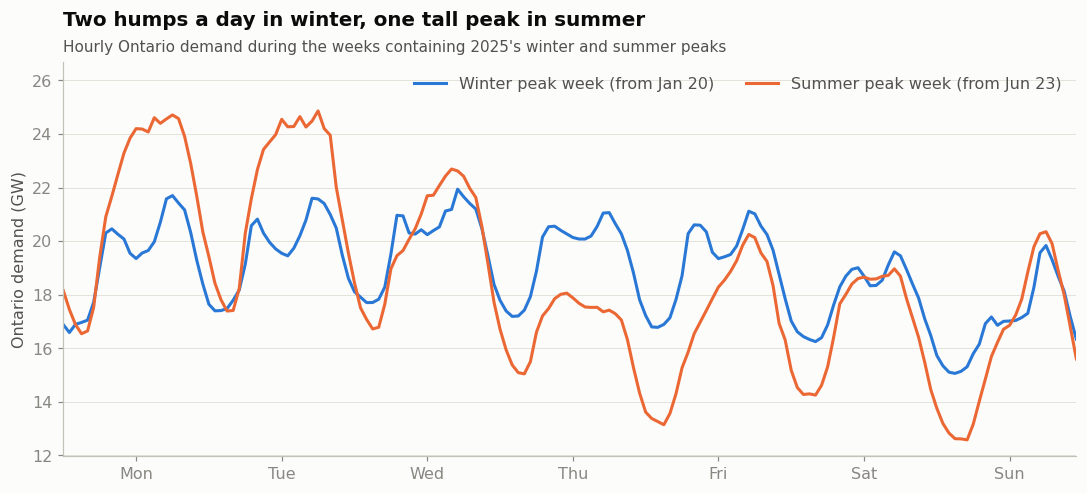

winter: peak 21,940 MW at Wed Jan 22 17:00 EST, min 15,063 MW, swing 6,877 MW
summer: peak 24,862 MW at Tue Jun 24 18:00 EST, min 12,582 MW, swing 12,280 MW


In [5]:
def peak_week(year, months):
    s = hourly.loc[str(year), "demand_mw"]
    s = s[s.index.month.isin(months)]
    start = s.idxmax().normalize() - pd.Timedelta(days=s.idxmax().weekday())
    return hourly.loc[start: start + pd.Timedelta(hours=167), "demand_mw"]

winter, summer = peak_week(2025, [1, 2]), peak_week(2025, [6, 7, 8])
fig, ax = plt.subplots()
for s, name, col in [(winter, "Winter peak week", C["blue"]), (summer, "Summer peak week", C["orange"])]:
    ax.plot(np.arange(len(s)), s.values / 1000, color=col, label=f"{name} (from {s.index[0]:%b %-d})")
ax.set_xticks(np.arange(0, 168, 24) + 12, ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xlim(0, 167)
ax.set_ylabel("Ontario demand (GW)")
ax.legend(loc="upper right", ncols=2)
ax.set_ylim(top=ax.get_ylim()[1] + 1.2)
headline(ax, "Two humps a day in winter, one tall peak in summer",
         "Hourly Ontario demand during the weeks containing 2025's winter and summer peaks")
plt.tight_layout(); plt.show()

for s, name in [(winter, "winter"), (summer, "summer")]:
    print(f"{name}: peak {s.max():,.0f} MW at {s.idxmax():%a %b %d %H:00} EST, "
          f"min {s.min():,.0f} MW, swing {s.max()-s.min():,.0f} MW")

The two shapes are different animals. A winter day has **two humps**: one as people wake
up and turn things on, a bigger one in the late afternoon and evening when lights, cooking
and heating stack on top of businesses that haven't closed yet. A summer heat-wave day has
**one tall peak** in the late afternoon, when buildings have soaked up the day's heat and
air conditioners are working hardest.

Notice the scale of the swing, too. In that summer week demand moved by about **12 GW**
between the quietest night and the peak hour, almost twice the winter week's range. The
summer peak, **24.9 GW** at 18:00 EST on June 24 (7 p.m. on the clock), was the highest
hour Ontario has seen since the early 2010s.

Also visible: the weekend. Saturday and Sunday sit lower in both weeks even though the
weather didn't take the weekend off.

Is that week typical? Overlaying every day of the month shows how much the shape
holds up from one day to the next.

January 2025: 31 days; average 15.9 GW at 03:00 -> 20.4 GW at 17:00 (swing 4.5 GW); busiest hour per day: {17: 25, 18: 6}
July 2025: 31 days; average 14.7 GW at 03:00 -> 21.7 GW at 16:00 (swing 7.1 GW); busiest hour per day: {13: 1, 14: 4, 15: 1, 16: 8, 17: 13, 18: 4}


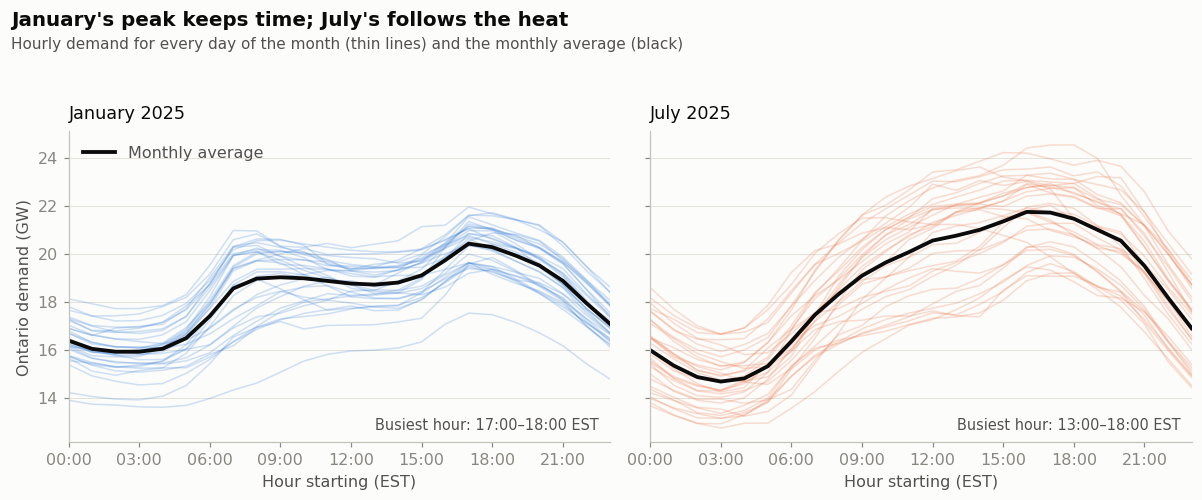

In [6]:
def month_profiles(year, month):
    s = hourly.loc[str(year), "demand_mw"]
    s = s[s.index.month == month]
    return s.groupby([s.index.date, s.index.hour]).mean().unstack() / 1000  # rows = days, cols = hour


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, (month, name, col) in zip(axes, [(1, "January 2025", C["blue"]), (7, "July 2025", C["orange"])]):
    days = month_profiles(2025, month)
    for _, day in days.iterrows():
        ax.plot(days.columns, day.values, color=col, alpha=0.22, lw=1)
    mean = days.mean()
    ax.plot(days.columns, mean.values, color=C["ink"], lw=2.5, label="Monthly average")
    peak_hours = days.idxmax(axis=1)
    ax.text(0.98, 0.04, f"Busiest hour: {peak_hours.min():02d}:00–{peak_hours.max():02d}:00 EST",
            transform=ax.transAxes, ha="right", fontsize=9.5, color=C["ink2"])
    ax.set_title(name, loc="left", fontsize=11.5, color=C["ink"], pad=8)
    ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
    ax.set_xlim(0, 23)
    ax.set_xlabel("Hour starting (EST)")
    print(f"{name}: {len(days)} days; average {mean.min():.1f} GW at {mean.idxmin():02d}:00 -> "
          f"{mean.max():.1f} GW at {mean.idxmax():02d}:00 (swing {mean.max() - mean.min():.1f} GW); "
          f"busiest hour per day: {peak_hours.value_counts().sort_index().to_dict()}")
axes[0].set_ylabel("Ontario demand (GW)")
axes[0].legend(loc="upper left")
fig.suptitle("January's peak keeps time; July's follows the heat", x=0.01, ha="left",
             fontsize=13, fontweight="bold", color=C["ink"])
fig.text(0.01, 0.905, "Hourly demand for every day of the month (thin lines) and the monthly average (black)",
         fontsize=10, color=C["ink2"])
plt.tight_layout(rect=(0, 0, 1, 0.9)); plt.show()

January's evening peak runs like a clock: on 25 of 31 days the busiest hour started
at 17:00 EST, and on the other six at 18:00. Cold days lift the whole curve rather than
reshaping it, so the spread between days is about the same at 3 a.m. as at the peak.
July is looser. The busiest hour wandered between 13:00 and 18:00 EST depending on when
the heat built up, and the average day swung **7 GW** from its overnight low to its
afternoon high, against **4.5 GW** in January.

**For the forecaster:** the shape of a winter day comes almost entirely from the
calendar; the shape of a summer day needs the hour-by-hour weather.

## Twenty years of demand

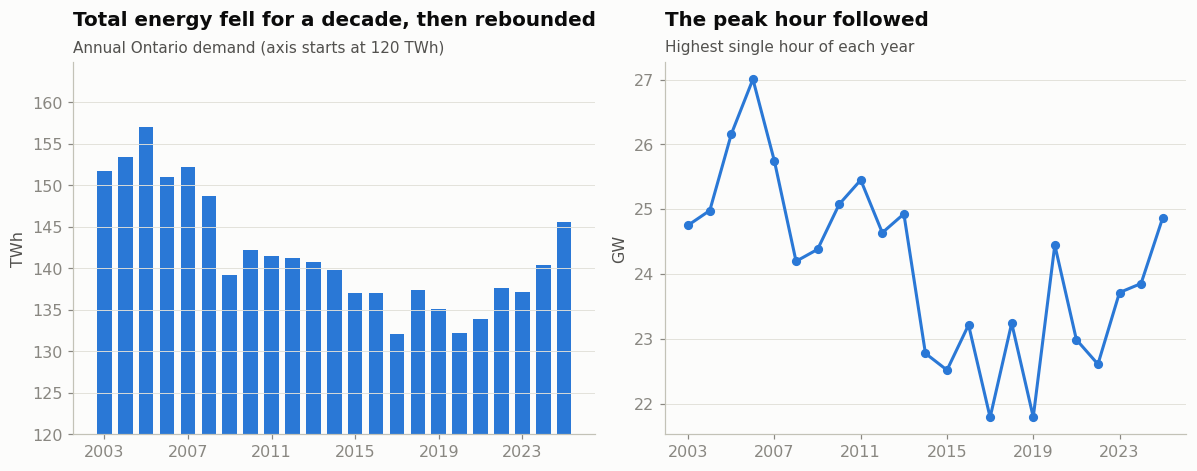

          energy_twh  peak_gw  hours
datetime                            
2003           151.7     24.8   8760
2004           153.4     25.0   8784
2005           157.0     26.2   8760
2006           151.1     27.0   8760
2007           152.2     25.7   8760
2008           148.7     24.2   8784
2009           139.2     24.4   8760
2010           142.2     25.1   8760
2011           141.5     25.4   8760
2012           141.3     24.6   8784
2013           140.7     24.9   8760
2014           139.8     22.8   8760
2015           137.0     22.5   8760
2016           137.0     23.2   8784
2017           132.1     21.8   8760
2018           137.4     23.2   8760
2019           135.1     21.8   8760
2020           132.2     24.4   8784
2021           133.8     23.0   8760
2022           137.6     22.6   8760
2023           137.1     23.7   8760
2024           140.4     23.9   8784
2025           145.6     24.9   8759

max energy 2005 157.0 TWh; min 2017 132.1 TWh (-15.9%); 2025 145.6 TWh (+1

In [7]:
annual = hourly.loc[FULL_YEARS, "demand_mw"].groupby(lambda t: t.year).agg(
    energy_twh=lambda s: s.sum() / 1e6, peak_gw=lambda s: s.max() / 1000, hours="count")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].bar(annual.index, annual["energy_twh"], color=C["blue"], width=0.7)
axes[0].set_ylim(120, annual["energy_twh"].max() * 1.05)
axes[0].set_ylabel("TWh")
headline(axes[0], "Total energy fell for a decade, then rebounded",
         "Annual Ontario demand (axis starts at 120 TWh)")
axes[1].plot(annual.index, annual["peak_gw"], color=C["blue"], marker="o", ms=5)
axes[1].set_ylabel("GW")
headline(axes[1], "The peak hour followed", "Highest single hour of each year")
for ax in axes:
    ax.set_xticks(range(2003, 2026, 4))
plt.tight_layout(); plt.show()

e = annual["energy_twh"]
print(annual.round(1).to_string())
print(f"\nmax energy {e.idxmax()} {e.max():.1f} TWh; min {e.idxmin()} {e.min():.1f} TWh "
      f"({(e.min()/e.max()-1)*100:+.1f}%); 2025 {e[2025]:.1f} TWh ({(e[2025]/e.min()-1)*100:+.1f}% vs min)")
print(f"peak max {annual['peak_gw'].idxmax()} {annual['peak_gw'].max():.2f} GW; 2025 {annual['peak_gw'][2025]:.2f}")

Zoom out and the story becomes one of decline and recovery. Ontario drew **157 TWh** in
2005. Twelve years later, in 2017, it drew **132 TWh**, about **16% less**, despite a
growing population. Canada's energy regulator
[traced the decline](https://www.cer-rec.gc.ca/en/data-analysis/energy-markets/market-snapshots/2018/market-snapshot-why-is-ontarios-electricity-demand-declining.html)
to a mix of conservation programs such as the IESO's Save on Energy, more efficient lighting
and appliances, an economy shifting from energy-intensive industry like pulp and paper toward
services, the 2009 recession, and a wave of solar panels installed after 2009. That last one
matters for how you read this chart:
[*Ontario Demand*](https://www.ieso.ca/power-data/demand-overview/real-time-demand-reports)
counts only energy supplied from the IESO-administered market, while generation connected to
local distribution networks
[offsets demand on the transmission grid](https://www.ieso.ca/en/Power-Data/Supply-Overview/Distribution-Connected-Generation)
before the IESO sees it. So some of the "decline" is load that moved off the grid's books
rather than load that disappeared.

Since 2017 the trend has turned. 2025 came in at **145.6 TWh**, up **10%** from the low,
and the peak hour has climbed back toward 25 GW. The IESO's planning outlooks attribute the
growth to
[electric-vehicle supply-chain manufacturing and data centres](https://ieso.ca/en/Powering-Tomorrow/2025/Seven-Graphs-and-a-Map-2025-Annual-Planning-Outlook),
[greenhouse expansion in the southwest](https://www.ieso.ca/en/Corporate-IESO/Media/News-Releases/2019/10/New-Greenhouse-Study),
and [electrification and population growth](https://ieso.ca/Sector-Participants/Planning-and-Forecasting/Annual-Planning-Outlook/2026-APO-Summary),
and the latest outlook expects demand to grow about 65% by 2050.

Could some of this twenty-year swing simply be the weather, a run of mild years followed by
harsher ones? That question deserves its own analysis, and it's the subject of a follow-up
post.

**For the forecaster:** the level of demand drifts over the years for reasons a weather model
never sees: the economy, efficiency, behind-the-meter generation and electrification. A
day-ahead model picks these up through lagged demand, since yesterday's load already reflects
today's economy; what it must avoid is learning its level from an era that no longer exists.
A forecast years ahead has no such shortcut and has to model those drivers explicitly.

## The daily rhythm changes with the seasons

January  min 14.8 GW @ 03h, max 19.6 GW @ 17h
April    min 12.5 GW @ 02h, max 15.9 GW @ 19h
July     min 13.4 GW @ 03h, max 19.9 GW @ 16h
October  min 12.2 GW @ 02h, max 16.4 GW @ 18h


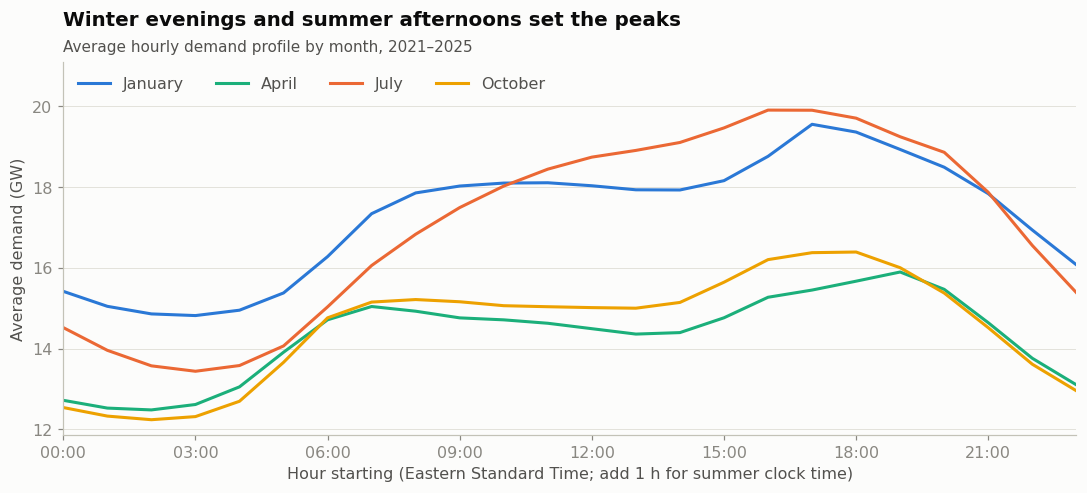

In [8]:
recent = hourly.loc["2021":"2025"].copy()
recent["hour"] = recent.index.hour
months = {1: ("January", C["blue"]), 4: ("April", C["aqua"]), 7: ("July", C["orange"]), 10: ("October", C["yellow"])}

fig, ax = plt.subplots()
for m, (name, col) in months.items():
    prof = recent[recent.index.month == m].groupby("hour")["demand_mw"].mean() / 1000
    ax.plot(prof.index, prof.values, color=col, label=name)
    print(f"{name:8s} min {prof.min():.1f} GW @ {prof.idxmin():02d}h, max {prof.max():.1f} GW @ {prof.idxmax():02d}h")
ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
ax.set_xlim(0, 23)
ax.set_xlabel("Hour starting (Eastern Standard Time; add 1 h for summer clock time)")
ax.set_ylabel("Average demand (GW)")
ax.legend(loc="upper left", ncols=4)
ax.set_ylim(top=ax.get_ylim()[1] + 0.8)
headline(ax, "Winter evenings and summer afternoons set the peaks",
         "Average hourly demand profile by month, 2021–2025")
plt.tight_layout(); plt.show()

Averaging over five years smooths the winter morning hump into a shoulder, but the
seasonal difference is clear. **July** climbs steadily all day and peaks at 16:00–17:00
EST (5–6 p.m. on the clock). **January** jumps early, holds a plateau through the working
day, and peaks at 17:00 EST, when darkness arrives before offices empty. The shoulder
months, **April** and **October**, are the quiet ones: no heating, no cooling, just the
baseline of a province going about its day.

The overnight trough is remarkably stable: 12–15 GW at 2–3 a.m. in every season. That
floor is Ontario's industrial and always-on load, and it's worth remembering later when we
talk about what the weather can't explain.

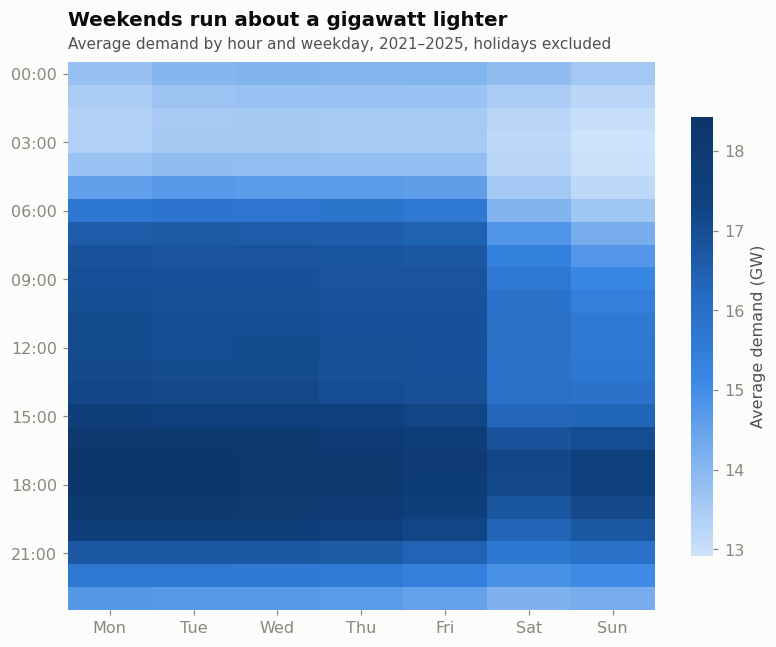

weekday mean 16.17 GW, weekend 15.16 GW, diff 1,017 MW (-6.3%)
daytime (09-17) weekday vs weekend diff: 1,172 MW


In [9]:
wk = recent.copy()
wk["dow"] = wk.index.dayofweek
wk = wk[~wk.index.normalize().isin(HOLIDAYS)]
grid = wk.pivot_table(index="hour", columns="dow", values="demand_mw", aggfunc="mean") / 1000

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(grid.values, aspect="auto", cmap=BLUES, origin="upper")
ax.set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_yticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("Average demand (GW)", color=C["ink2"]); cb.outline.set_visible(False)
headline(ax, "Weekends run about a gigawatt lighter", "Average demand by hour and weekday, 2021–2025, holidays excluded")
plt.tight_layout(); plt.show()

wkday, wkend = grid.iloc[:, :5].mean().mean(), grid.iloc[:, 5:].mean().mean()
print(f"weekday mean {wkday:.2f} GW, weekend {wkend:.2f} GW, diff {(wkday-wkend)*1000:,.0f} MW ({(wkend/wkday-1)*100:.1f}%)")
print("daytime (09-17) weekday vs weekend diff:",
      f"{(grid.iloc[9:18, :5].mean().mean()-grid.iloc[9:18, 5:].mean().mean())*1000:,.0f} MW")

The week has its own shape. Monday through Friday are nearly identical; Saturday and
Sunday are about **1 GW (6%) lighter** on average, and the gap is widest during working
hours. Weekend mornings also start later: the dark band that marks the weekday morning
ramp arrives an hour or two late on Saturday and later still on Sunday.

## Enter the weather: the U-curve

Now the main character. If you plot every hour's demand against the temperature at that
hour, twenty years of data collapse into a single, very recognisable shape.

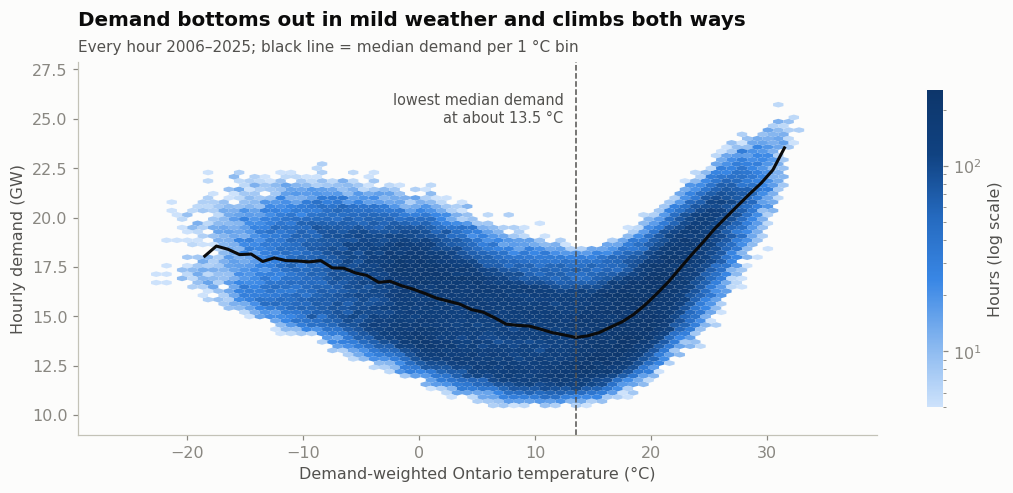

hours: 175,315; balance point 13.5 C; median at balance 13.92 GW
  median at -18.5 C: 18.05 GW
  median at -9.5 C: 17.75 GW
  median at +0.5 C: 16.15 GW
  median at +10.5 C: 14.34 GW
  median at +25.5 C: 19.44 GW
  median at +30.5 C: 22.41 GW


In [10]:
wx = hourly.loc[WX_YEARS].dropna(subset=["demand_mw", "temp_c"])

fig, ax = plt.subplots()
hb = ax.hexbin(wx["temp_c"], wx["demand_mw"] / 1000, gridsize=70, cmap=BLUES, mincnt=5, bins="log", linewidths=0)
bins = np.arange(np.floor(wx["temp_c"].min()), np.ceil(wx["temp_c"].max()) + 1, 1.0)
g = wx.groupby(pd.cut(wx["temp_c"], bins), observed=True)["demand_mw"]
med = g.median()[g.count() >= 200] / 1000
mid = np.array([iv.mid for iv in med.index])
ax.plot(mid, med.values, color=C["ink"], lw=2)
balance = mid[np.argmin(med.values)]
ax.axvline(balance, color=C["ink2"], lw=1, ls="--")
ax.annotate(f"lowest median demand\nat about {balance:.1f} °C", (balance, 25.5), xytext=(-8, 0),
            textcoords="offset points", ha="right", va="center", color=C["ink2"], fontsize=9.5)
ax.set_xlabel("Demand-weighted Ontario temperature (°C)")
ax.set_ylabel("Hourly demand (GW)")
ax.grid(False)
cb = fig.colorbar(hb, ax=ax, shrink=0.85); cb.set_label("Hours (log scale)", color=C["ink2"]); cb.outline.set_visible(False)
headline(ax, "Demand bottoms out in mild weather and climbs both ways",
         "Every hour 2006–2025; black line = median demand per 1 °C bin")
plt.tight_layout(); plt.show()

print(f"hours: {len(wx):,}; balance point {balance:.1f} C; median at balance {med.min():.2f} GW")
for t in [-20, -10, 0, 10, 25, 30]:
    i = np.argmin(abs(mid - (t + 0.5)))
    print(f"  median at {mid[i]:+.1f} C: {med.values[i]:.2f} GW")

This is the **U-curve**, and it's the single most important picture in load forecasting.
Demand is lowest at around **13–14 °C**, a temperature where nobody needs heating or
cooling. Move away from it in either direction and demand climbs.

But the U is lopsided. From the bottom of the curve out to 30 °C, median demand rises by
more than **8 GW**. Going the other way, down to −18 °C, adds only about **4 GW**. Ontario
mostly heats with natural gas, so cold weather reaches the electricity grid indirectly,
through furnace fans, block heaters, longer lighting hours, and the minority of homes with
electric heat. Heat, on the other hand, runs straight into air conditioners, which are
almost all electric.

The vertical spread matters as much as the median line. At any given temperature there's
a band of 5–6 GW between busy and quiet hours. That spread is the time of day, the day of
the week, and the long-term trend, all folded together. We'll pull those apart next.

## How many megawatts per degree?

Hourly data mixes the temperature effect with the daily rhythm. Averaging to **daily**
values removes most of that, and makes the relationship clean enough to fit with straight
lines: a heating slope below one temperature, a cooling slope above another, and a flat
zone in between. The two breakpoints are chosen to fit recent weekdays best.

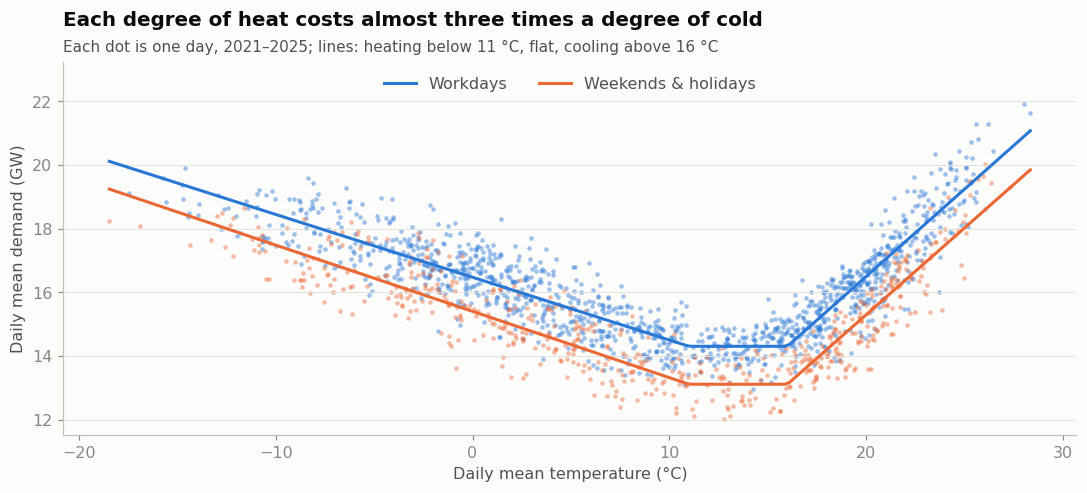

breakpoints: heating below 11.0 C, cooling above 16.0 C; workday R2 0.805
workday heating slope 197 MW per C below; cooling slope 548 MW per C above
flat-zone workday level 14,304 MW


In [11]:
def to_daily(h):
    d = h.resample("D").agg({"demand_mw": "mean", "temp_c": "mean", "dew_c": "mean", "wind_kph": "mean"})
    d["dow"] = d.index.dayofweek
    d["holiday"] = d.index.isin(HOLIDAYS)
    d["workday"] = (d["dow"] < 5) & ~d["holiday"]
    return d.dropna(subset=["demand_mw", "temp_c"])

daily = to_daily(hourly.loc[WX_YEARS])


def hinge_fit(d, th, tc):
    X = np.column_stack([np.maximum(th - d["temp_c"], 0), np.maximum(d["temp_c"] - tc, 0)])
    m = LinearRegression().fit(X, d["demand_mw"])
    return m, m.score(X, d["demand_mw"])


# Heating below TH, cooling above TC, flat in between; breakpoints by grid search
# on recent workdays so the long-run trend and weekends don't blur the slopes.
rec = daily.loc["2021":"2025"]
rec_w = rec[rec["workday"]]
TH, TC = max(((th, tc) for th in np.arange(8, 20.5, 0.5) for tc in np.arange(12, 24.5, 0.5) if tc >= th),
             key=lambda p: hinge_fit(rec_w, *p)[1])
m_work, r2_work = hinge_fit(rec_w, TH, TC)

fig, ax = plt.subplots()
for mask, name, col in [(rec["workday"], "Workdays", C["blue"]), (~rec["workday"], "Weekends & holidays", C["orange"])]:
    sub = rec[mask]
    ax.scatter(sub["temp_c"], sub["demand_mw"] / 1000, s=9, alpha=0.45, color=col, lw=0)
    m, _ = hinge_fit(sub, TH, TC)
    t = np.linspace(rec["temp_c"].min(), rec["temp_c"].max(), 200)
    y = m.predict(np.column_stack([np.maximum(TH - t, 0), np.maximum(t - TC, 0)])) / 1000
    ax.plot(t, y, color=col, label=name)
ax.legend(loc="upper center", ncols=2)
ax.set_ylim(top=ax.get_ylim()[1] + 0.8)
ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("Daily mean demand (GW)")
headline(ax, "Each degree of heat costs almost three times a degree of cold",
         f"Each dot is one day, 2021–2025; lines: heating below {TH:.0f} °C, flat, cooling above {TC:.0f} °C")
plt.tight_layout(); plt.show()

print(f"breakpoints: heating below {TH:.1f} C, cooling above {TC:.1f} C; workday R2 {r2_work:.3f}")
print(f"workday heating slope {m_work.coef_[0]:,.0f} MW per C below; cooling slope {m_work.coef_[1]:,.0f} MW per C above")
print(f"flat-zone workday level {m_work.intercept_:,.0f} MW")

Three straight lines explain **80%** of the day-to-day variation in workday demand, using
nothing but the daily mean temperature. The best breakpoints are **11 °C** and **16 °C**:
between them, the weather barely matters.

The slopes are the headline numbers:

| | Workday demand change |
|---|---|
| Each °C colder than 11 °C | **+197 MW** |
| Each °C warmer than 16 °C | **+548 MW** |

So each degree of heat adds nearly **three times** as much load as a degree of cold. A
summer day averaging 26 °C (a hot one, since the average includes the night) puts about
5.5 GW on the grid above a mild day. Weekends follow the same shape, shifted down by
roughly a gigawatt, which is the calendar effect from earlier showing up again.

## It's not the heat, it's the humidity

Anyone who has lived through a Toronto summer knows 28 °C and dry is not the same as
28 °C and sticky. The grid seems to know it too. Here are summer weekday afternoons,
grouped by dew point (a measure of how much moisture is in the air).

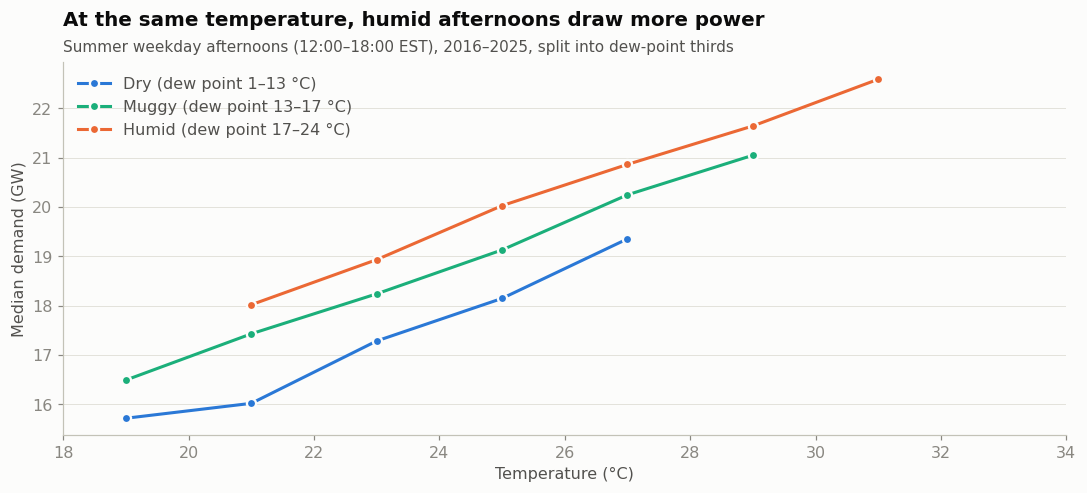

dew_group      Dry    Muggy    Humid
tbin                                
(18, 20]   15720.0  16494.0  17504.0
(20, 22]   16022.0  17431.0  18020.0
(22, 24]   17286.0  18241.0  18934.0
(24, 26]   18148.0  19131.0  20028.0
(26, 28]   19355.0  20248.0  20864.0
(28, 30]   19678.0  21049.0  21643.0
(30, 32]   20692.0  21617.0  22590.0
(32, 34]       NaN  22014.0  24269.0


In [12]:
summer_pm = hourly.loc["2016":"2025"].dropna(subset=["temp_c", "dew_c", "demand_mw"])
summer_pm = summer_pm[summer_pm.index.month.isin([6, 7, 8]) & summer_pm.index.hour.isin(range(12, 18))
                      & (summer_pm.index.dayofweek < 5)]
summer_pm = summer_pm[~summer_pm.index.normalize().isin(HOLIDAYS)]
summer_pm["dew_group"] = pd.qcut(summer_pm["dew_c"], 3, labels=["Dry", "Muggy", "Humid"])
summer_pm["tbin"] = pd.cut(summer_pm["temp_c"], np.arange(18, 36, 2))

fig, ax = plt.subplots()
tab = summer_pm.groupby(["dew_group", "tbin"], observed=True)["demand_mw"].agg(["median", "count"])
for grp, col in zip(["Dry", "Muggy", "Humid"], [C["blue"], C["aqua"], C["orange"]]):
    s = tab.loc[grp]
    s = s[s["count"] >= 40]
    lo, hi = summer_pm.loc[summer_pm["dew_group"] == grp, "dew_c"].agg(["min", "max"])
    ax.plot([iv.mid for iv in s.index], s["median"] / 1000, color=col, marker="o", ms=6,
            mec=C["surface"], mew=1.5, label=f"{grp} (dew point {lo:.0f}–{hi:.0f} °C)")
ax.set_xlim(18, 34)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Median demand (GW)")
ax.legend(loc="upper left")
headline(ax, "At the same temperature, humid afternoons draw more power",
         "Summer weekday afternoons (12:00–18:00 EST), 2016–2025, split into dew-point thirds")
plt.tight_layout(); plt.show()

print(tab.unstack("dew_group")["median"].round(0).to_string())

At every temperature, the humid line sits above the dry one, by roughly **1.5–2 GW**.
Part of that is physics: air conditioners spend energy removing moisture, not just heat,
and people run them harder when it's muggy. Part of it is correlation: humid days tend to
come in multi-day heat waves, when buildings have had no chance to cool off overnight.
Either way the lesson for a model is the same: **temperature alone understates summer
demand**, and dew point (or a humidex-style index) earns its place as a feature.

## Is the grid getting more sensitive to the weather?

If the cooling slope is ~550 MW per degree today, was it always? Fitting the same
three-line model to each year's workdays separately:

cooling: 459 (2006-10 avg) -> 547 (2021-25 avg), +19%; trend +6.8/yr
heating: 182 (2006-10 avg) -> 196 (2021-25 avg), +8%; trend +1.2/yr


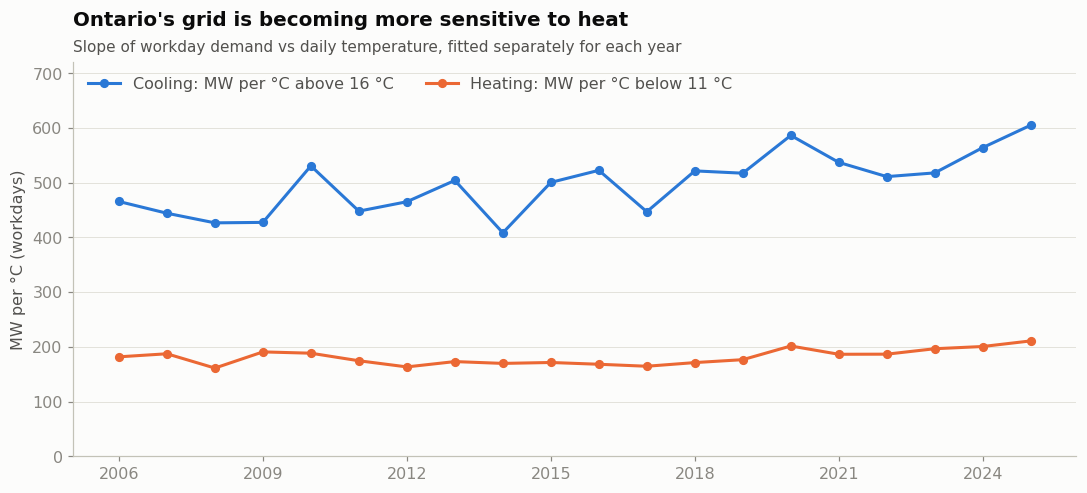

      heating  cooling     r2
year                         
2006    182.0    466.0  0.863
2007    187.0    444.0  0.881
2008    161.0    427.0  0.847
2009    191.0    427.0  0.884
2010    188.0    531.0  0.919
2011    175.0    448.0  0.895
2012    163.0    465.0  0.884
2013    173.0    504.0  0.876
2014    170.0    408.0  0.903
2015    171.0    501.0  0.898
2016    168.0    523.0  0.894
2017    165.0    447.0  0.845
2018    171.0    522.0  0.847
2019    177.0    517.0  0.898
2020    202.0    586.0  0.789
2021    186.0    537.0  0.853
2022    187.0    511.0  0.868
2023    197.0    518.0  0.817
2024    201.0    564.0  0.883
2025    211.0    605.0  0.893


In [13]:
rows = []
for y, d in daily[daily["workday"]].groupby(daily[daily["workday"]].index.year):
    m, r2 = hinge_fit(d, TH, TC)
    rows.append({"year": y, "heating": m.coef_[0], "cooling": m.coef_[1], "r2": r2})
sens = pd.DataFrame(rows).set_index("year")

fig, ax = plt.subplots()
for col_name, name, col in [("cooling", f"Cooling: MW per °C above {TC:.0f} °C", C["blue"]),
                            ("heating", f"Heating: MW per °C below {TH:.0f} °C", C["orange"])]:
    ax.plot(sens.index, sens[col_name], color=col, marker="o", ms=5, label=name)
    slope = np.polyfit(sens.index, sens[col_name], 1)[0]
    print(f"{col_name}: {sens[col_name].iloc[:5].mean():.0f} (2006-10 avg) -> {sens[col_name].iloc[-5:].mean():.0f} "
          f"(2021-25 avg), {(sens[col_name].iloc[-5:].mean()/sens[col_name].iloc[:5].mean()-1)*100:+.0f}%; trend {slope:+.1f}/yr")
ax.set_xticks(range(2006, 2026, 3))
ax.set_ylabel("MW per °C (workdays)")
ax.set_ylim(0, 720)
ax.legend(loc="upper left", ncols=2)
headline(ax, "Ontario's grid is becoming more sensitive to heat",
         "Slope of workday demand vs daily temperature, fitted separately for each year")
plt.tight_layout(); plt.show()
print(sens.round({"heating": 0, "cooling": 0, "r2": 3}).to_string())

Cooling sensitivity has risen from about **460 MW/°C** (2006–2010 average) to about
**550 MW/°C** (2021–2025), roughly **+19%**, with 2025 the highest year on record at
over 600 MW/°C. More air conditioning in more homes, larger homes, and a growing population
all push the same way. 2020 stands out as well: with people working from home, the
province's air conditioners were running in houses instead of offices, and the slope
jumped.

Heating sensitivity is flatter but has also crept up recently, to above 200 MW/°C in 2024
and 2025. That's what you'd expect as heat pumps start to replace gas furnaces. It's early,
but it's the signal to watch: electrified heating would make the cold side of the U much
steeper.

**For the forecaster:** the weather response isn't fixed. A model that learns "one degree
is worth X megawatts" from 2010 data will underestimate today's heat-wave peaks. Either
weight recent data more heavily, or let the temperature effect interact with a trend.

## What the weather can't explain: the calendar

To separate the calendar from the weather, I fit one regression on 2017–2019 daily data (before the pandemic) with the heating and cooling terms, a humidity interaction, a linear trend, and indicators for each weekday, statutory holidays, and the week between Christmas and New Year. Weather and calendar together explain **90%** of the day-to-day variation in 2017–2019 (in-sample R² = 0.90), and the calendar coefficients read directly as megawatts:

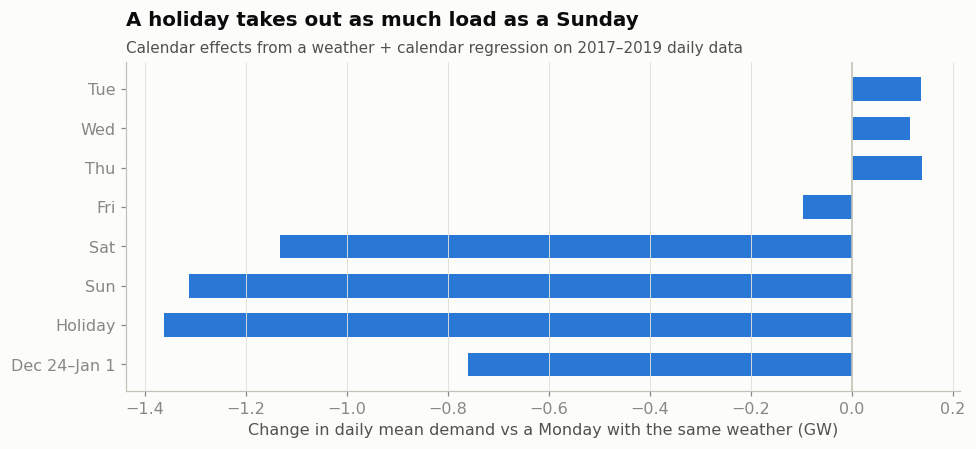

heat             177.0
cool             198.0
cool_x_dew        18.0
Tue              136.0
Wed              114.0
Thu              138.0
Fri              -97.0
Sat            -1132.0
Sun            -1312.0
Holiday        -1362.0
Dec 24–Jan 1    -761.0
trend            113.0
R2 train 0.905; residual sd 473 MW


In [14]:
def design(d):
    X = pd.DataFrame(index=d.index)
    X["heat"] = np.maximum(TH - d["temp_c"], 0)
    X["cool"] = np.maximum(d["temp_c"] - TC, 0)
    X["cool_x_dew"] = X["cool"] * d["dew_c"]
    for k, name in enumerate(["Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], start=1):
        X[name] = (d["dow"] == k).astype(float)
    X["Holiday"] = d["holiday"].astype(float)
    X["Dec 24–Jan 1"] = ((d.index.month == 12) & (d.index.day >= 24) | (d.index.month == 1) & (d.index.day == 1)).astype(float)
    X["trend"] = (d.index.year - 2017) + d.index.dayofyear / 365.25
    return X

train = daily.loc["2017":"2019"].dropna(subset=["dew_c"])
cal_model = LinearRegression().fit(design(train), train["demand_mw"])
coef = pd.Series(cal_model.coef_, index=design(train).columns)
resid_sd = (train["demand_mw"] - cal_model.predict(design(train))).std()

effects = coef[["Tue", "Wed", "Thu", "Fri", "Sat", "Sun", "Holiday", "Dec 24–Jan 1"]]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(effects.index[::-1], effects.values[::-1] / 1000, color=C["blue"], height=0.6)
ax.axvline(0, color=C["axis"], lw=1)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("Change in daily mean demand vs a Monday with the same weather (GW)")
headline(ax, "A holiday takes out as much load as a Sunday",
         "Calendar effects from a weather + calendar regression on 2017–2019 daily data")
plt.tight_layout(); plt.show()

print(coef.round(0).to_string())
print(f"R2 train {cal_model.score(design(train), train['demand_mw']):.3f}; residual sd {resid_sd:,.0f} MW")

Relative to a Monday with identical weather, Tuesday through Thursday are slightly busier
(about +0.1 GW) and Friday a little lighter. Saturday removes **1.1 GW** and Sunday
**1.3 GW**. A statutory holiday removes **1.4 GW**, so a holiday Monday behaves like a
Sunday. The holiday week at the end of December removes another **0.8 GW** on top of any
weekend or holiday, as offices and factories close between the holidays.

After weather and calendar, the typical daily error is about **470 MW**, around 3% of
average demand. That's a decent first benchmark for the forecasting models to beat, with
one caveat: it uses the *actual* weather, which a real forecast won't have.

## A natural experiment: spring 2020

A model that knows the weather and the calendar can answer a counterfactual question: what
*should* demand have been? Spring 2020 is the most dramatic test there is.

The model from the previous section was fit on 2017–2019 only, so every day on the chart
below, from January 2020 on, is out of sample. It is fed the weather that actually
happened, which makes this a counterfactual ("what would demand have been, given that
weather?") rather than a forecast.

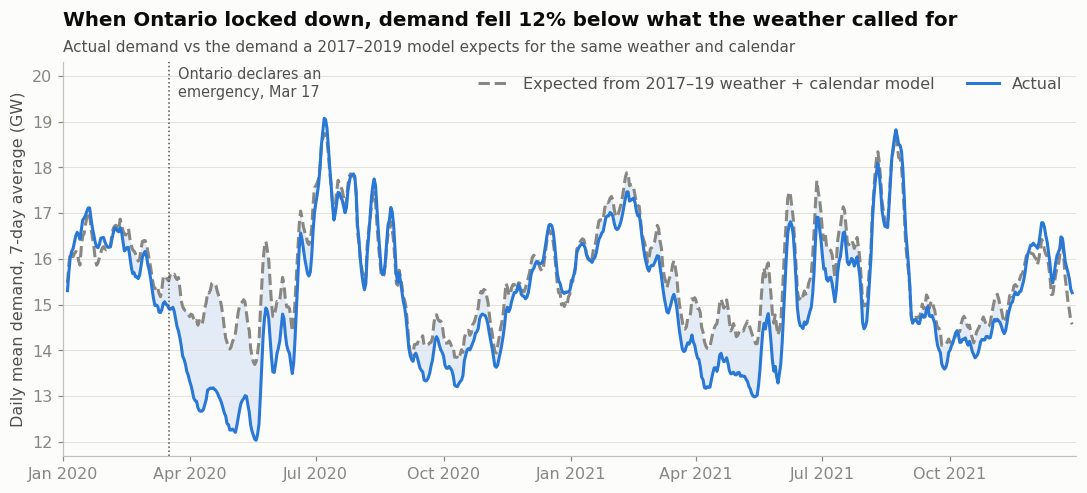

Jan 1 - Mar 15 2020          mean gap -0.5%
Mar 23 - May 31 2020         mean gap -11.9%
Jun - Dec 2020               mean gap -1.8%
2021                         mean gap -2.6%
deepest 7-day gap -15.5% week ending May 09


In [15]:
test = daily.loc["2020":"2021"].dropna(subset=["dew_c"]).copy()
test["expected"] = cal_model.predict(design(test))
test["gap_pct"] = (test["demand_mw"] / test["expected"] - 1) * 100
roll = test[["demand_mw", "expected"]].rolling(7, center=True).mean() / 1000

fig, ax = plt.subplots()
ax.plot(roll.index, roll["expected"], color=C["muted"], lw=2, ls="--", label="Expected from 2017–19 weather + calendar model")
ax.plot(roll.index, roll["demand_mw"], color=C["blue"], label="Actual")
ax.fill_between(roll.index, roll["demand_mw"], roll["expected"], where=roll["demand_mw"] < roll["expected"],
                color=C["blue"], alpha=0.12, lw=0)
ax.axvline(pd.Timestamp("2020-03-17"), color=C["ink2"], lw=1, ls=":")
ax.annotate("Ontario declares an\nemergency, Mar 17", (pd.Timestamp("2020-03-17"), 20.2),
            xytext=(6, 0), textcoords="offset points", color=C["ink2"], fontsize=9.5, va="top")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"))
ax.set_ylim(top=20.3)
ax.set_ylabel("Daily mean demand, 7-day average (GW)")
ax.legend(loc="upper right", ncols=2)
headline(ax, "When Ontario locked down, demand fell 12% below what the weather called for",
         "Actual demand vs the demand a 2017–2019 model expects for the same weather and calendar")
plt.tight_layout(); plt.show()

for a, b, name in [("2020-01-01", "2020-03-15", "Jan 1 - Mar 15 2020"),
                   ("2020-03-23", "2020-05-31", "Mar 23 - May 31 2020"),
                   ("2020-06-01", "2020-12-31", "Jun - Dec 2020"),
                   ("2021-01-01", "2021-12-31", "2021")]:
    print(f"{name:28s} mean gap {test.loc[a:b, 'gap_pct'].mean():+.1f}%")
w = test.loc["2020-03-15":"2020-06-30", "gap_pct"].rolling(7).mean()
print(f"deepest 7-day gap {w.min():.1f}% week ending {w.idxmin():%b %d}")

Through the first ten weeks of 2020, out of sample and before the pandemic arrived, the model tracks reality within half a percent.
Then Ontario declared a state of emergency on March 17, and demand fell away from the
dashed line. From late March to the end of May it averaged **12% below** what the weather
and calendar predicted, bottoming out about **15.5% below** in early May. Offices,
schools, restaurants and many factories closed; the extra household use didn't come close
to making up for them.

The gap mostly closed over the summer (a hot summer with everyone home kept air
conditioners busy), and by the second half of 2020 demand was within about 2% of
expectations. A smaller shortfall persists into 2021, which is some mix of lasting
changes in how people work and a three-year-old model drifting out of date.

**For the forecaster:** 2020 is not like the other years. It should be flagged or
down-weighted in training, and it's a reminder that no amount of weather data will
predict a policy shock.

## Demand remembers

The last property matters more for forecasting than for understanding: how much does
demand at one hour tell you about demand at another?

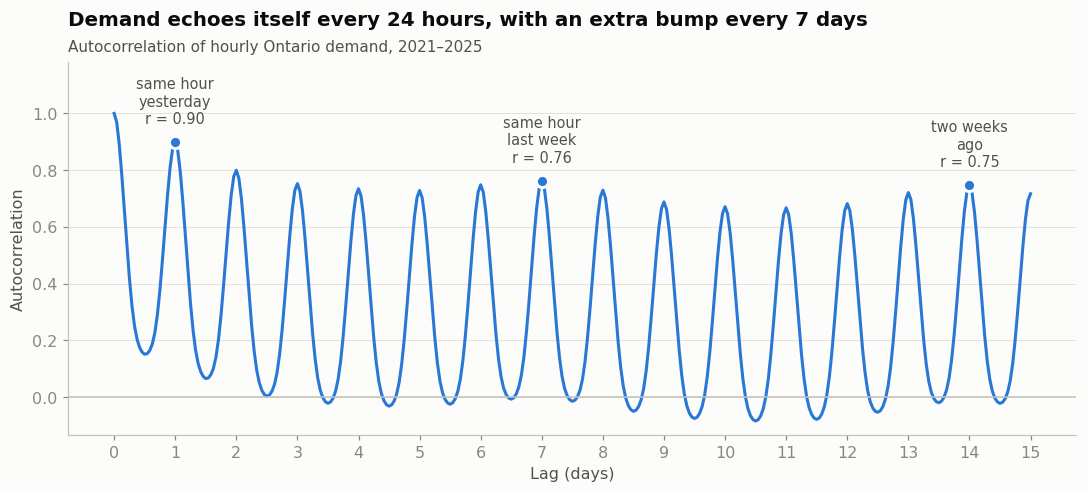

lag   1h r=0.970
lag   2h r=0.893
lag  12h r=0.151
lag  24h r=0.899
lag  48h r=0.800
lag 144h r=0.748
lag 168h r=0.763
lag 192h r=0.730
lag 336h r=0.748


In [16]:
series = hourly.loc["2021":"2025", "demand_mw"].interpolate(limit=3).dropna()
lags = 24 * 15
r = acf(series, nlags=lags, fft=True)

fig, ax = plt.subplots()
ax.plot(np.arange(lags + 1), r, color=C["blue"])
for L, txt in [(24, "same hour\nyesterday"), (168, "same hour\nlast week"), (336, "two weeks\nago")]:
    ax.plot(L, r[L], "o", color=C["blue"], ms=8, mec=C["surface"], mew=2)
    ax.annotate(f"{txt}\nr = {r[L]:.2f}", (L, r[L]), xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=9.5, color=C["ink2"])
ax.axhline(0, color=C["axis"], lw=1)
ax.set_xticks(range(0, lags + 1, 24), [str(d) for d in range(0, 16)])
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
ax.set_ylim(min(r.min(), 0) - 0.05, 1.18)
headline(ax, "Demand echoes itself every 24 hours, with an extra bump every 7 days",
         "Autocorrelation of hourly Ontario demand, 2021–2025")
plt.tight_layout(); plt.show()
for L in [1, 2, 12, 24, 48, 144, 168, 192, 336]:
    print(f"lag {L:3d}h r={r[L]:.3f}")

Demand is strongly autocorrelated. The previous hour explains almost everything
(r = 0.97), which is why very-short-term forecasts are easy. More useful for a day-ahead
forecast are the daily peaks: the **same hour yesterday** has a correlation of **0.90**.
The peaks slowly decay as you go further back, except for a small bump at **7 and 14
days**: the same hour on the same weekday. A forecasting model should be given exactly
these as inputs: demand 24 hours ago, 48 hours ago, and one week ago.

## What this means for a forecast

Pulling it all together, here's what Ontario's demand is made of, and what a model will
need to see:

| What we found | Size | Feature for the model |
|---|---|---|
| Demand bottoms out at 11–16 °C and rises both ways | the U-curve | heating & cooling degrees (hinged temperature) |
| Heat costs ~550 MW/°C, cold ~200 MW/°C | ~3× asymmetry | separate heating and cooling terms, not a single temperature |
| Humidity adds load at the same temperature | +1.5–2 GW on muggy afternoons | dew point, or cooling × dew point |
| Heat sensitivity has grown ~19% since 2006 | +7 MW/°C per year | trend term, or weight recent years more |
| Weekends and holidays are ~1.1–1.4 GW lighter | ~7–9% | day of week, holiday flag, Christmas week |
| The shape of the day depends on the season | two humps vs one peak | hour × season (or hour × temperature) interactions |
| Demand echoes itself | r = 0.90 at 24 h | lagged demand at 24 h, 48 h, 168 h |
| 2020 broke the rules | −12% for ten weeks | flag or down-weight the pandemic period |
| Demand fell until 2017, now rising | −16% then +10% | don't train only on old data |

A simple daily model built from these pieces already gets within about 3% on a typical
day, but only because it was handed the *real* weather. In practice a forecast only has a
weather forecast, which is itself wrong in ways that matter most on exactly the hottest
and coldest days. That's the next post: building the model, and checking how much of its
accuracy survives when it has to use forecast weather instead of the truth.

---

*Data: IESO Public Reports (Ontario Demand); Environment and Climate Change Canada
hourly climate observations (Open Government Licence – Canada).*

*Analysis and drafting done with the help of [Claude Code](https://claude.com/claude-code);
questions, judgement calls and editing are mine. Every number in the text comes from the
notebook.*